# WGCNA Module Analysis and GO Enrichment

Like a main cohort, we performed de novo WGCNA on validation cohort.

Before running this notebook, please run the R codes (WGCNA_microglia(astrocyte)_val.R). You will need pb_Microglia(Astrocytes)_control_filtered.csv to run the R codes. You will get three result csv files for each cell type. 
1. df_tom_similarity_microglia(astrocyte)_val.csv
2. df_zsummary_microglia(astrocyte)_val.csv
3. modules_whole_microglia(astrocyte)_val.csv

Total 6 files should be copied on the ~/data/validation_cohort/GSE254569/WGCNA_modules directory before running the code below. 

This notebook analyzes WGCNA modules for Microglia and Astrocytes, performs GO enrichment analysis using GSEApy, and visualizes the results.

In [1]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Add sources directory to path
sys.path.append('../../sources')
import wgcna_utils as wu

In [2]:
# Parameters
root_path = "/data/home/swkim0523/research/_SCZ_mic_ast_fin_0511/data/validation_cohort/GSE254569"
data_dir = f"{root_path}/WGCNA_modules"
output_base_dir = f"{root_path}/WGCNA_GO_enrichr"
z_summary_thres = 2
cell_types = ['microglia', 'astrocyte']

os.makedirs(output_base_dir, exist_ok=True)

In [3]:
# ── Global style ──────────────────────────────────
plt.rcParams.update({
    "font.family": "Liberation Serif",
    "font.size": 9,
    "mathtext.default": "regular",
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
})

for ct in cell_types:
    print(f"\n{'='*20} Processing: {ct} {'='*20}")
    
    # 1. Load modules filtered by Z-summary
    z_summary_path = os.path.join(data_dir, f'df_zsummary_{ct}_val.csv')
    module_csv_path = os.path.join(data_dir, f'modules_whole_{ct}_val.csv')
    
    ct_modules, module_mapping = wu.get_module_dict(
        ct, z_summary_path, module_csv_path, z_summary_thres=z_summary_thres
    )
    
    # Save module mapping
    mapping_df = pd.DataFrame([module_mapping]).T
    mapping_df.columns = ['Module_Number']
    mapping_df.to_csv(os.path.join(data_dir, f'{ct}_module_number_mapping_val.csv'))
    
    # 2. Run GO Enrichment and Plot
    ct_output_dir = os.path.join(output_base_dir, f'GO_enrichr_{ct}')
    
    # Set plot color map based on cell type
    cmap = plt.cm.OrRd
    
    for m_idx in sorted(ct_modules.keys()):
        print(f"Processing {ct} Module {m_idx}...")
        
        # Run enrichment
        res_df = wu.run_go_enrichment(ct_modules[m_idx], ct, m_idx, ct_output_dir)
        
        # Plot results (top 10)
        if not res_df.empty:
            wu.plot_go_results(res_df, ct, m_idx, ct_output_dir, n_top=10, color_map=cmap)
            
    print(f"Done processing {ct}!")


==================== Processing: microglia ====================
Module 1: 422 genes
Module 2: 1520 genes
Module 3: 1481 genes
Module 4: 175 genes
Module 5: 87 genes
Module 6: 101 genes
Module 8: 145 genes
Module 9: 167 genes
Module 10: 130 genes
Module 11: 265 genes
Module 12: 80 genes
Module 13: 259 genes
Module 14: 572 genes
Module 15: 119 genes
Module 16: 218 genes
Module 17: 2970 genes
Module 18: 661 genes
Processing microglia Module 1...
Processing microglia Module 2...
Processing microglia Module 3...
Processing microglia Module 4...
Processing microglia Module 5...
Processing microglia Module 6...
Processing microglia Module 8...
Processing microglia Module 9...
Processing microglia Module 10...
Processing microglia Module 11...
Processing microglia Module 12...
Processing microglia Module 13...
Processing microglia Module 14...
Processing microglia Module 15...
Processing microglia Module 16...
Processing microglia Module 17...
Processing microglia Module 18...
Done processing

Universe genes: 11646
Primary Ast15 genes (in universe): 335
Module 1: 606 genes
Module 2: 1176 genes
Module 3: 998 genes
Module 4: 350 genes
Module 6: 723 genes
Module 7: 434 genes
Module 8: 234 genes
Module 9: 308 genes
Module 10: 218 genes
Module 11: 185 genes
Module 12: 496 genes
Module 13: 327 genes
Module 14: 597 genes
Module 15: 471 genes
Module 16: 619 genes
Module 17: 413 genes
Module 18: 1348 genes
Module 19: 758 genes


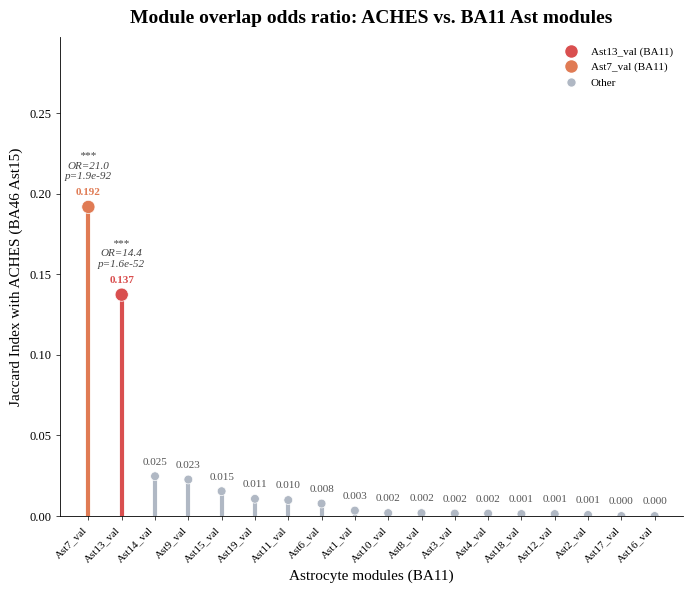

In [4]:
# ── 3. Module Overlap Analysis (BA11 Ast vs BA46 Ast15) ──────────────────
from scipy.stats import fisher_exact
from matplotlib.lines import Line2D

# 1. Load Primary Ast15 genes (BA46)
primary_wgcna_dir = "/data/home/swkim0523/research/_SCZ_mic_ast_fin_0511/data/primary_cohort/WGCNA_modules"
df_primary_mod = pd.read_csv(f"{primary_wgcna_dir}/modules_whole_astrocyte.csv", index_col=0)
ast15_genes = set(df_primary_mod[df_primary_mod['dynamicColors'] == 'pink']['genes'])

# 2. Load background genes (universe) - common genes between cohorts
primary_pb_path = "/data/home/swkim0523/research/_SCZ_mic_ast_fin_0511/data/primary_cohort/pb_ct_filtered/pb_astrocyte_control_filtered.csv"
val_pb_path = f"{root_path}/pb_ct_filtered/pb_Astrocytes_control_filtered.csv"

df_primary_pb = pd.read_csv(primary_pb_path, index_col=0)
df_val_pb = pd.read_csv(val_pb_path, index_col=0)

universe_genes = set(df_primary_pb.columns) & set(df_val_pb.columns)
n_universe = len(universe_genes)
ast15_genes_filt = ast15_genes & universe_genes

print(f"Universe genes: {n_universe}")
print(f"Primary Ast15 genes (in universe): {len(ast15_genes_filt)}")

# 3. Calculate Overlaps for BA11 astrocyte modules
z_summary_path = os.path.join(data_dir, 'df_zsummary_astrocyte_val.csv')
module_csv_path = os.path.join(data_dir, 'modules_whole_astrocyte_val.csv')
val_ast_modules, _ = wu.get_module_dict('astrocyte', z_summary_path, module_csv_path, z_summary_thres=2)

results = []
for m_idx, m_genes in val_ast_modules.items():
    m_genes_set = set(m_genes) & universe_genes
    overlap = ast15_genes_filt & m_genes_set
    
    jaccard = len(overlap) / len(ast15_genes_filt | m_genes_set) if len(ast15_genes_filt | m_genes_set) > 0 else 0
    
    # Fisher table
    a = len(overlap)
    b = len(ast15_genes_filt) - a
    c = len(m_genes_set) - a
    d = n_universe - (a + b + c)
    
    odds, pval = fisher_exact([[a, b], [c, d]], alternative='greater')
    
    results.append({
        'module': f'Ast{m_idx}_val',
        'jaccard': jaccard,
        'odds': odds,
        'pval': pval
    })

df_overlap = pd.DataFrame(results).sort_values('jaccard', ascending=False)

# ── 4. Visualization: Lollipop Plot ────────────────────────────────────
highlight = {'Ast7_val': '#E07B54', 'Ast13_val': '#D94F4F'}
default_color = '#B0B8C4'

colors = [highlight.get(m, default_color) for m in df_overlap['module']]
sizes  = [90 if m in highlight else 40 for m in df_overlap['module']]

plt.rcParams['font.family'] = 'Liberation Serif'
fig, ax = plt.subplots(figsize=(7, 6))
x = np.arange(len(df_overlap))

ax.vlines(x, 0, df_overlap['jaccard'], color=colors, linewidth=3, zorder=1)
ax.scatter(x, df_overlap['jaccard'], color=colors, s=sizes, zorder=2, edgecolors='white', linewidth=0.5)


for i, (_, row) in enumerate(df_overlap.iterrows()):
    mod = row['module']
    val = row['jaccard']
    is_hl = mod in highlight
    
    # Jaccard 지수 텍스트 표시
    if val >= 0:
        ax.text(i, val + 0.006, f'{val:.3f}', ha='center', va='bottom', fontsize=8, 
                fontweight='bold' if is_hl else 'normal', color=highlight.get(mod, '#555555'))
    
    # P-value 및 Odds Ratio 표시 조건 수정 (0.001 미만일 때만)
    if row['pval'] < 0.001:  # <--- 이 부분을 <= 1 에서 < 0.001 로 수정
        ax.text(i, val + 0.016, f"***\nOR={row['odds']:.1f}\np={row['pval']:.1e}",
                ha='center', va='bottom', fontsize=8, color='#444444', style='italic', linespacing=1.2)


ax.set_xticks(x)
ax.set_xticklabels(df_overlap['module'], fontsize=8, rotation=45, ha='right')
ax.set_ylabel('Jaccard Index with ACHES (BA46 Ast15)', fontsize=11)
ax.set_xlabel('Astrocyte modules (BA11)', fontsize=11)
ax.set_title('Module overlap odds ratio: ACHES vs. BA11 Ast modules', fontsize=14, fontweight="bold", pad=10)
ax.set_ylim(0, df_overlap['jaccard'].max() * 1.55)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#D94F4F', markersize=10, label='Ast13_val (BA11)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#E07B54', markersize=10, label='Ast7_val (BA11)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#B0B8C4', markersize=7, label='Other'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=8, frameon=False)

plt.tight_layout()
plt.savefig(os.path.join('/data/home/swkim0523/research/_SCZ_mic_ast_fin_0511/figures', 'fig5d_module_overlap_jaccard_Ast15.png'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join('/data/home/swkim0523/research/_SCZ_mic_ast_fin_0511/figures', 'fig5d_module_overlap_jaccard_Ast15.svg'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join('/data/home/swkim0523/research/_SCZ_mic_ast_fin_0511/figures', 'fig5d_module_overlap_jaccard_Ast15.pdf'), dpi=300, bbox_inches='tight')
plt.show()